In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def plot_model(dataset, model, id, timestamp, steps_ahead, freq_delta, plt_tmp=plt):
    df = pd.read_csv(f"model_results/{dataset}/{model}/median_preds.csv", index_col=0, parse_dates=['ds'])
    lower_df = pd.read_csv(f"model_results/{dataset}/{model}/quantile_10_preds.csv", index_col=0, parse_dates=['ds'])
    higher_df = pd.read_csv(f"model_results/{dataset}/{model}/quantile_90_preds.csv", index_col=0, parse_dates=['ds'])

    x = [timestamp+freq_delta*i for i in range(1,steps_ahead+1)]
    plt_tmp.plot(x, df.loc[(df["unique_id"]==id) & (df["ds"]==timestamp), [str(i) for i in range(1,steps_ahead+1)]].to_numpy().flatten(), label=f"{model_name}", linewidth=1, c='b')
    lower_pred = lower_df.loc[(df["unique_id"]==id) & (df["ds"]==timestamp), [str(i) for i in range(1,steps_ahead+1)]].to_numpy().flatten()
    higher_pred = higher_df.loc[(df["unique_id"]==id) & (df["ds"]==timestamp), [str(i) for i in range(1,steps_ahead+1)]].to_numpy().flatten()
    plt_tmp.fill_between(x, lower_pred, higher_pred, color='b', alpha=0.3)  

def plot_true(dataset, id, timestamp, graph_before, steps_ahead, freq_delta, plt_tmp=plt):
    df_true = pd.read_csv(f"data/{dataset}/y_{dataset}.csv", index_col=0, parse_dates=['ds'])
    true_y = df_true.loc[(df_true["unique_id"]==id) & (df_true["ds"]>=timestamp-graph_before*freq_delta) & (df_true["ds"]<timestamp+steps_ahead*freq_delta), "y"].to_numpy().flatten()
    plt_tmp.plot(df_true.loc[(df_true["unique_id"]==id) & (df_true["ds"]>=timestamp-graph_before*freq_delta) & (df_true["ds"]<timestamp+steps_ahead*freq_delta), "ds"].to_numpy().flatten(), true_y, label=f"True", linewidth=1, color='r')

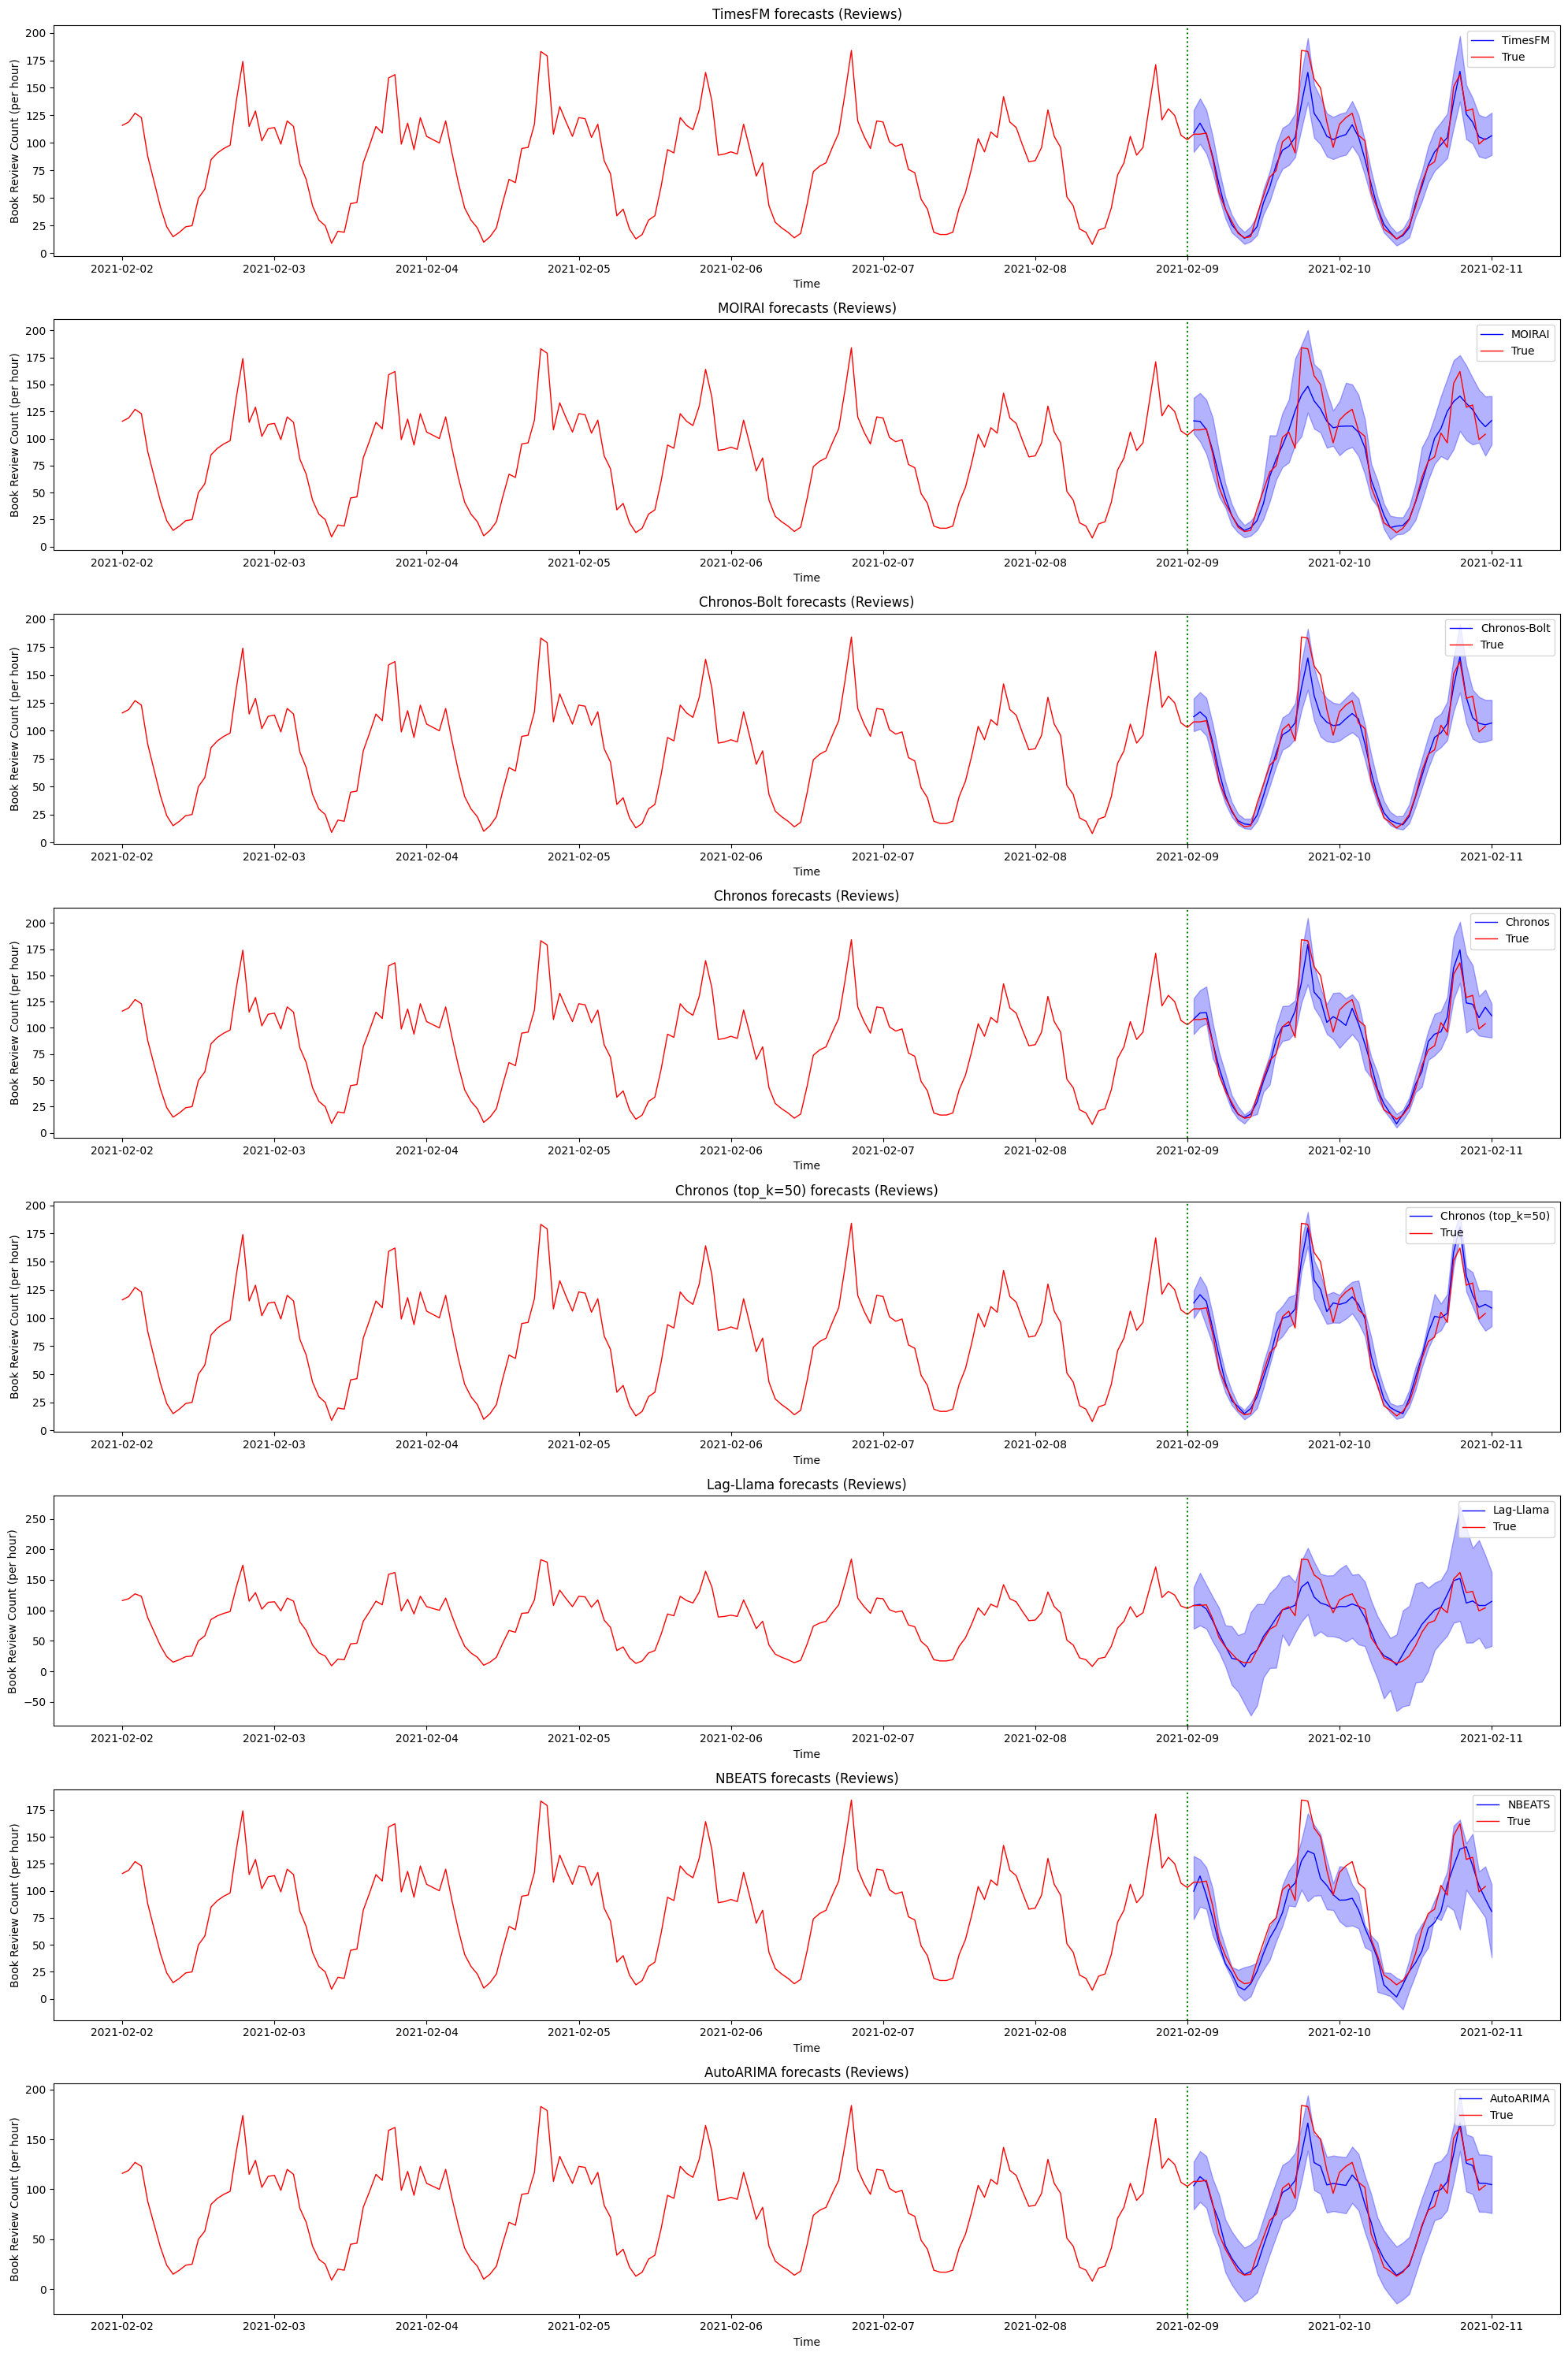

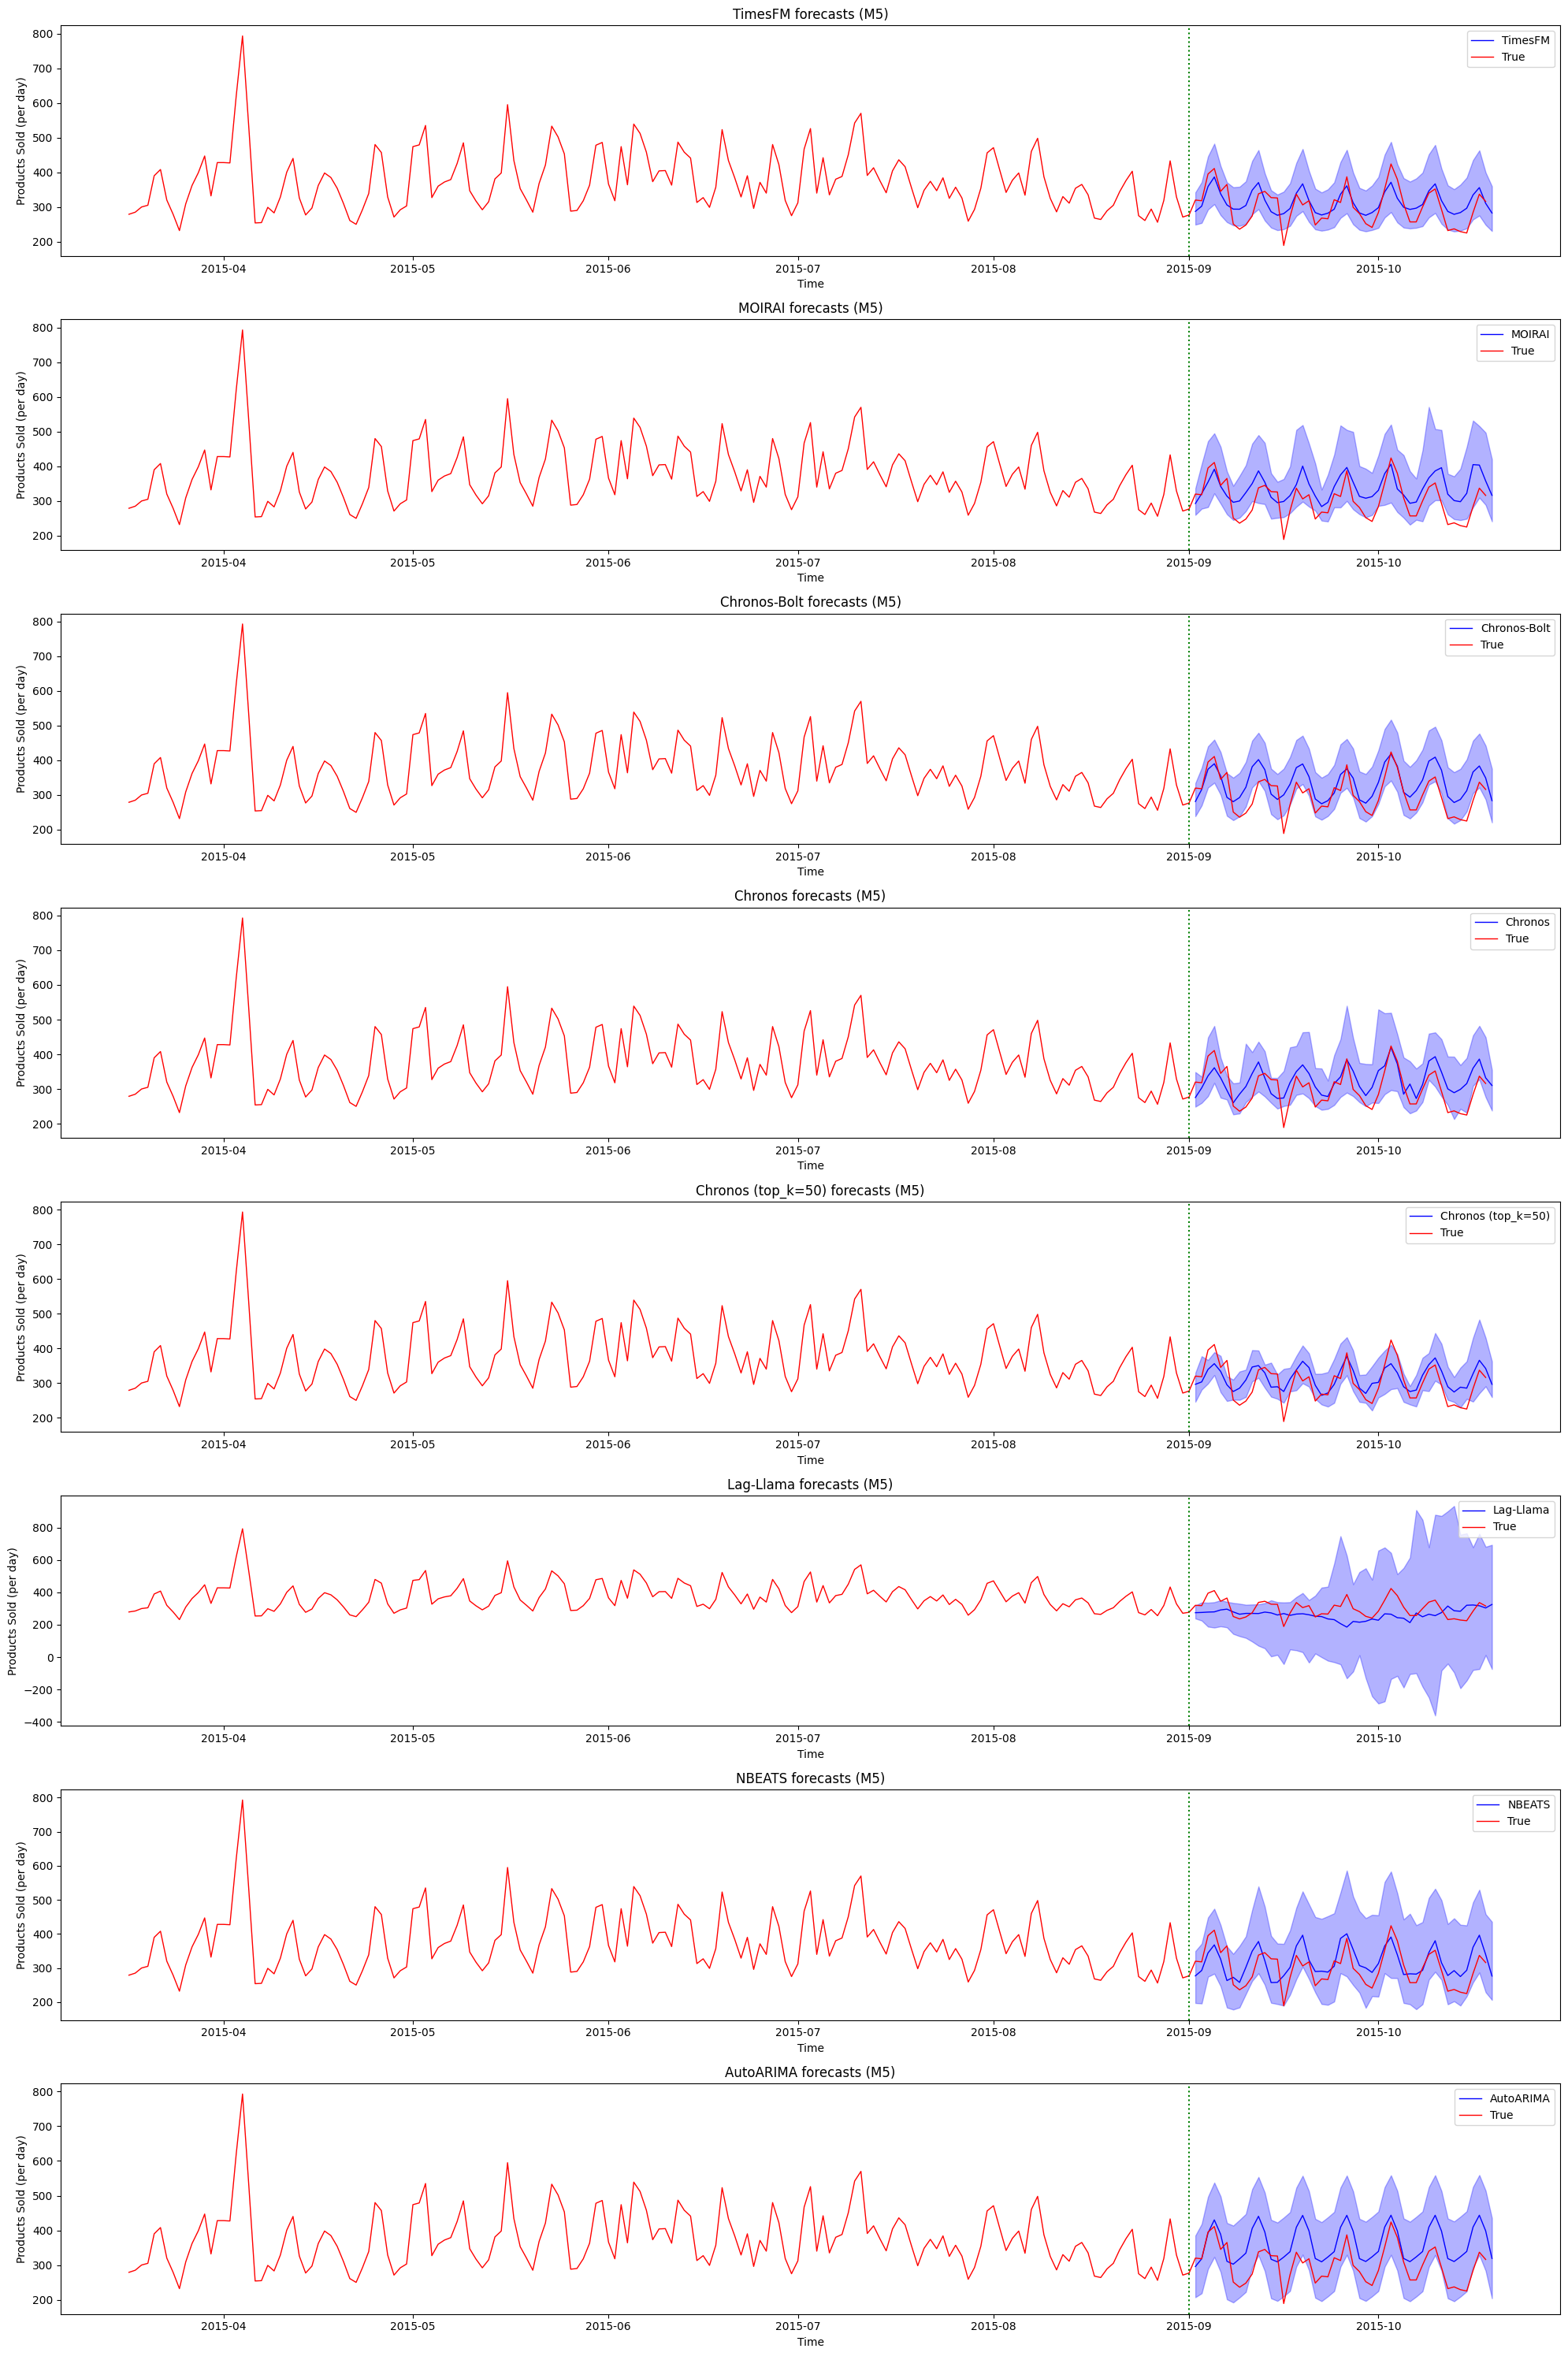

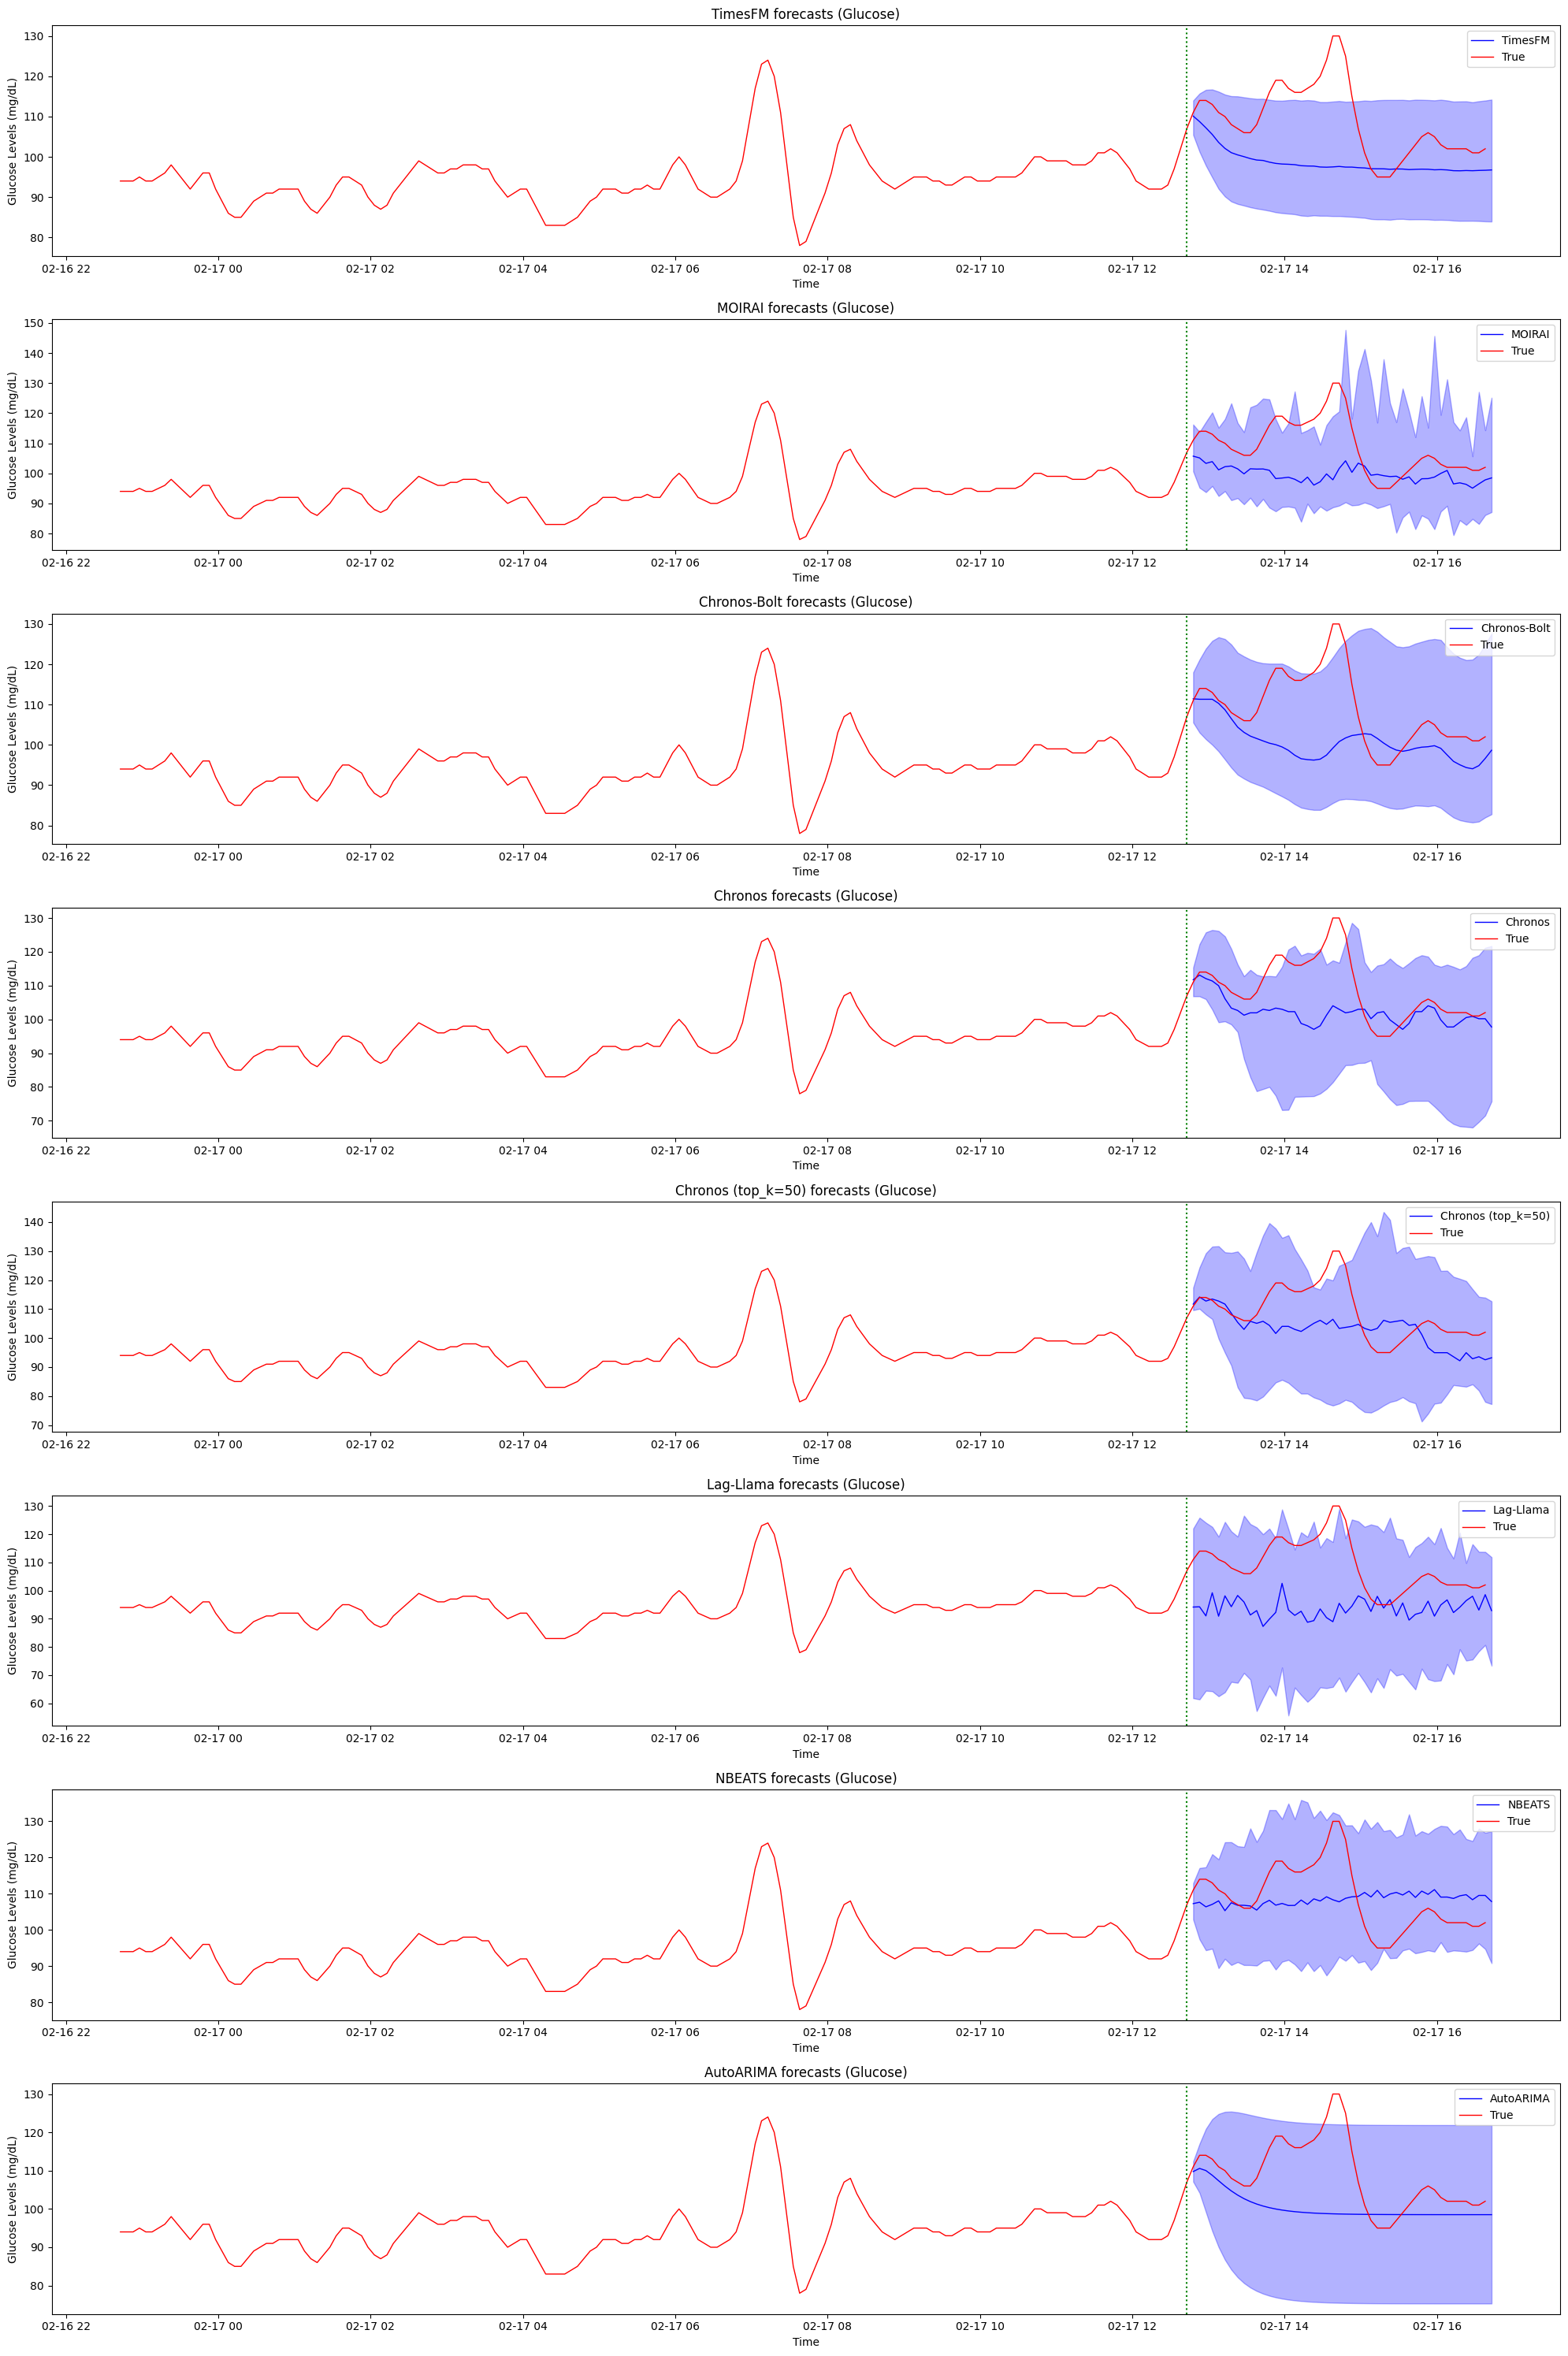

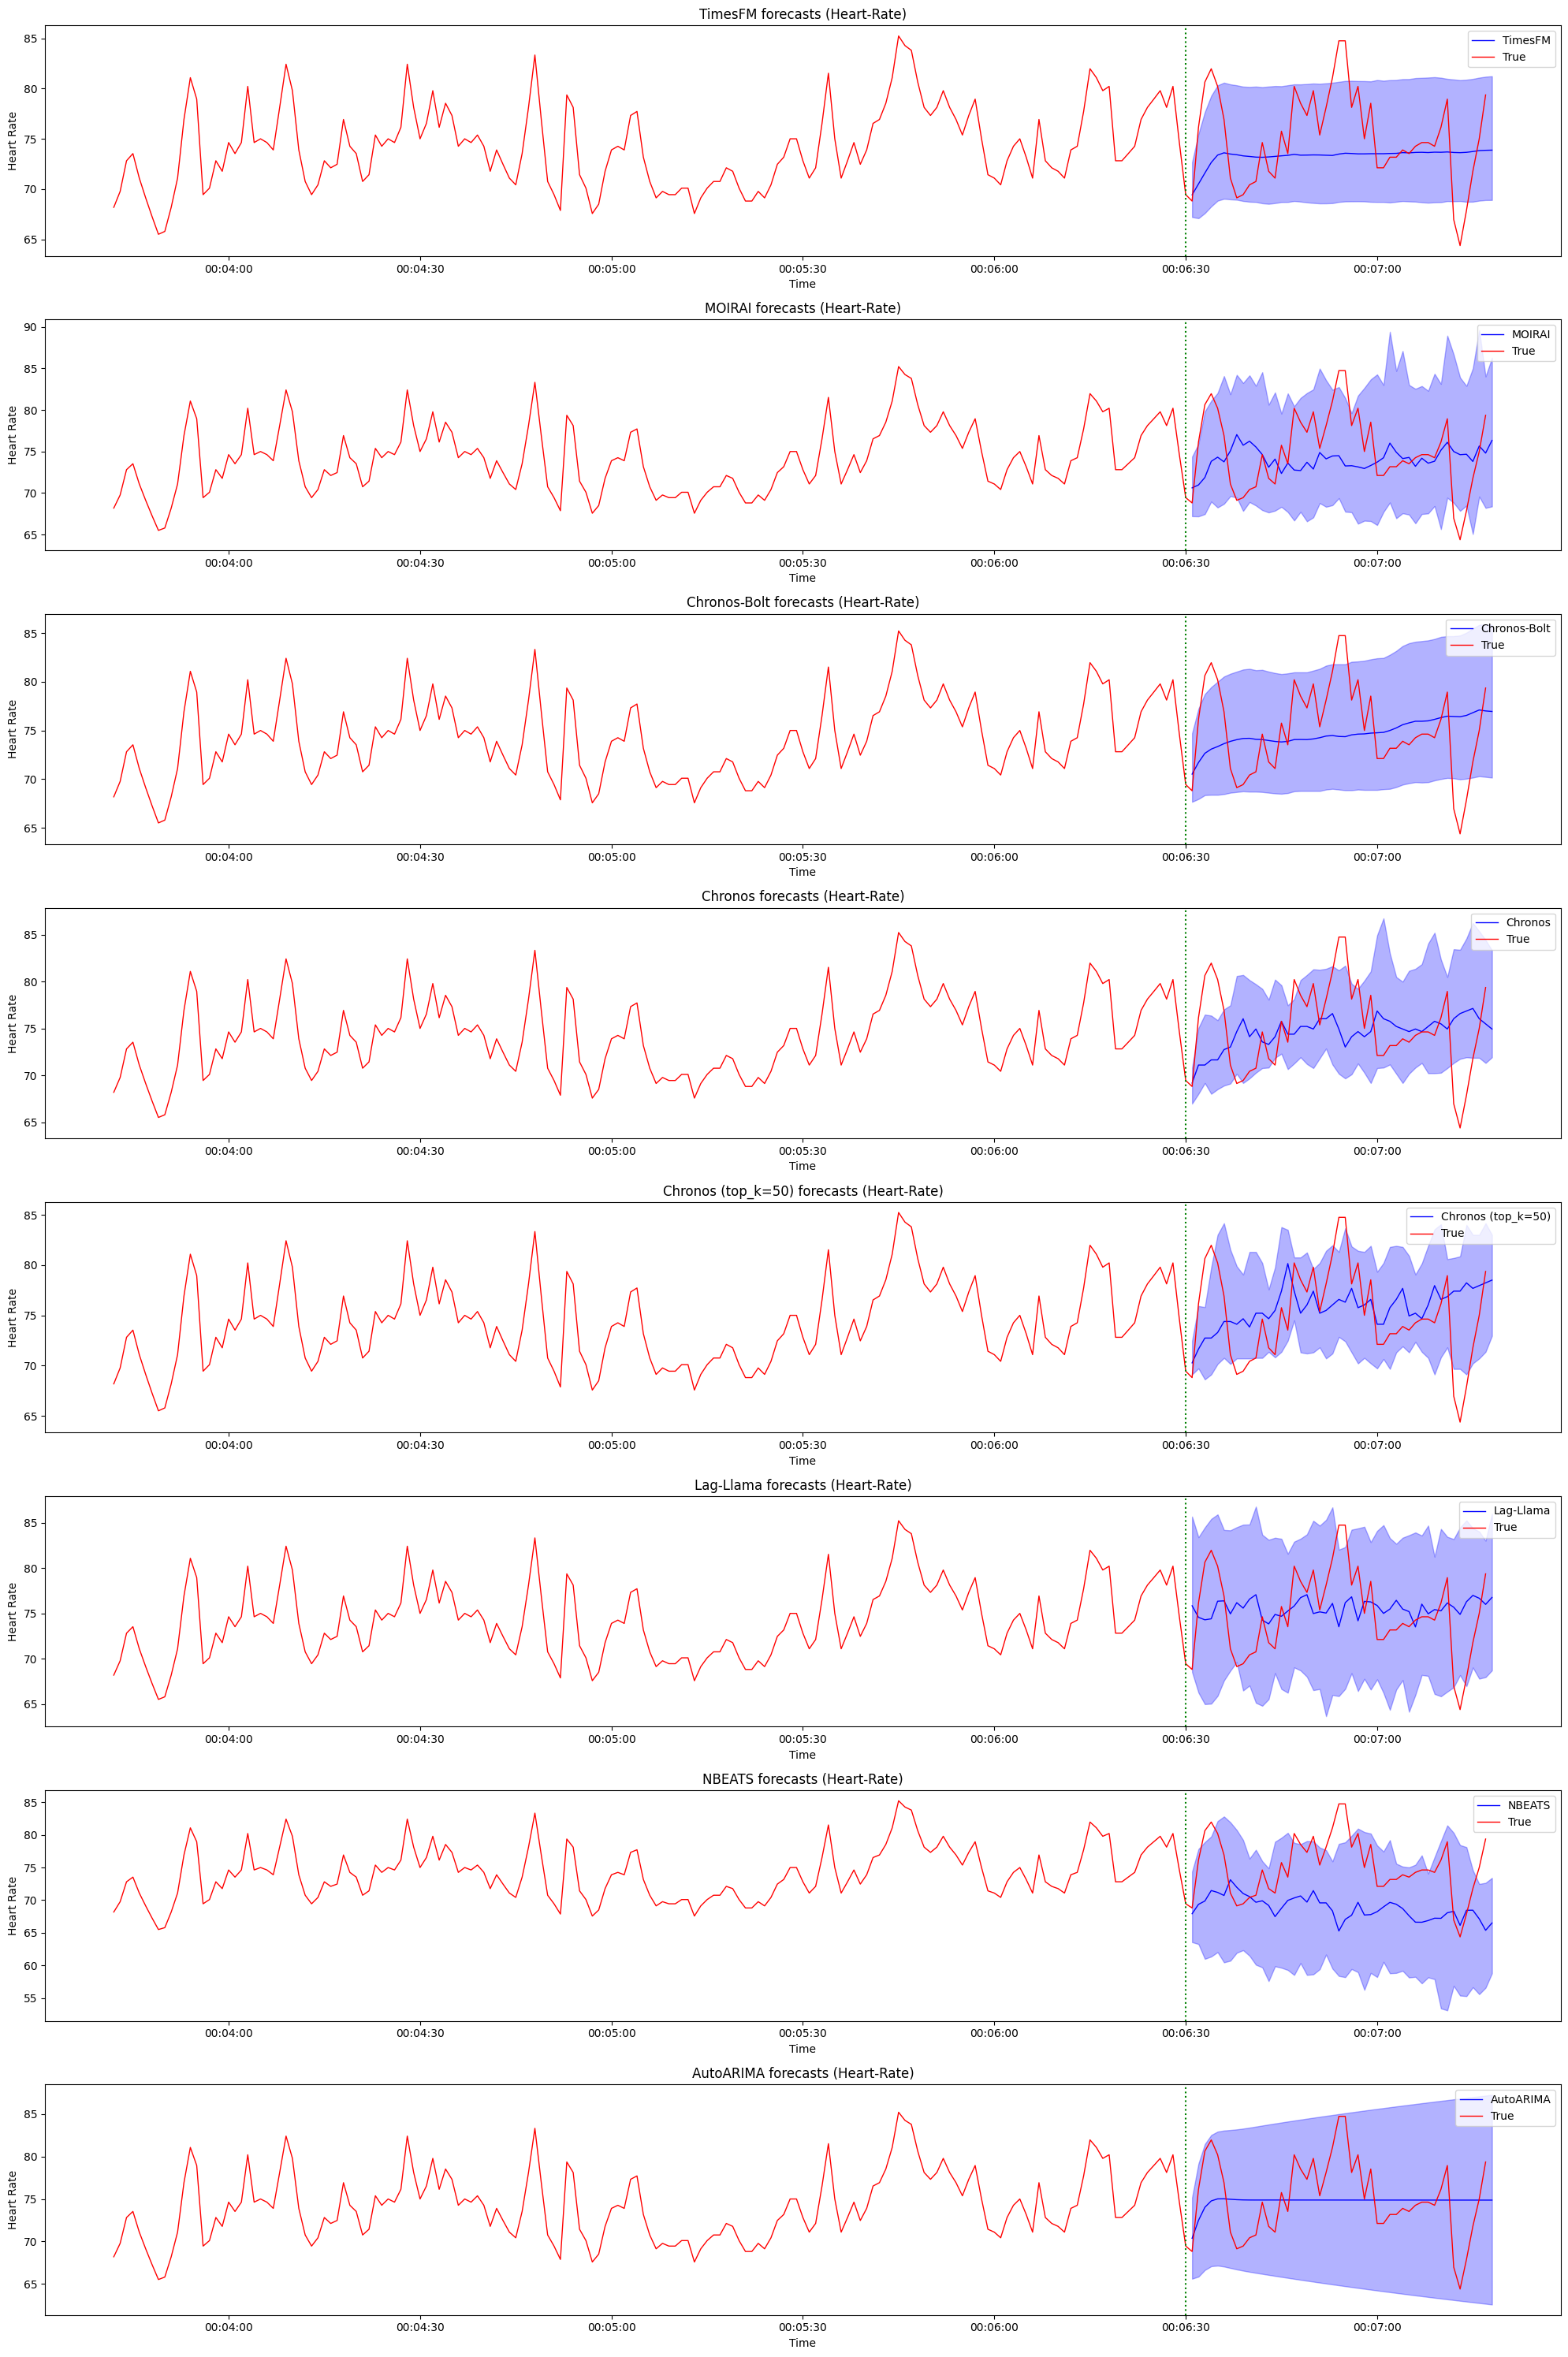

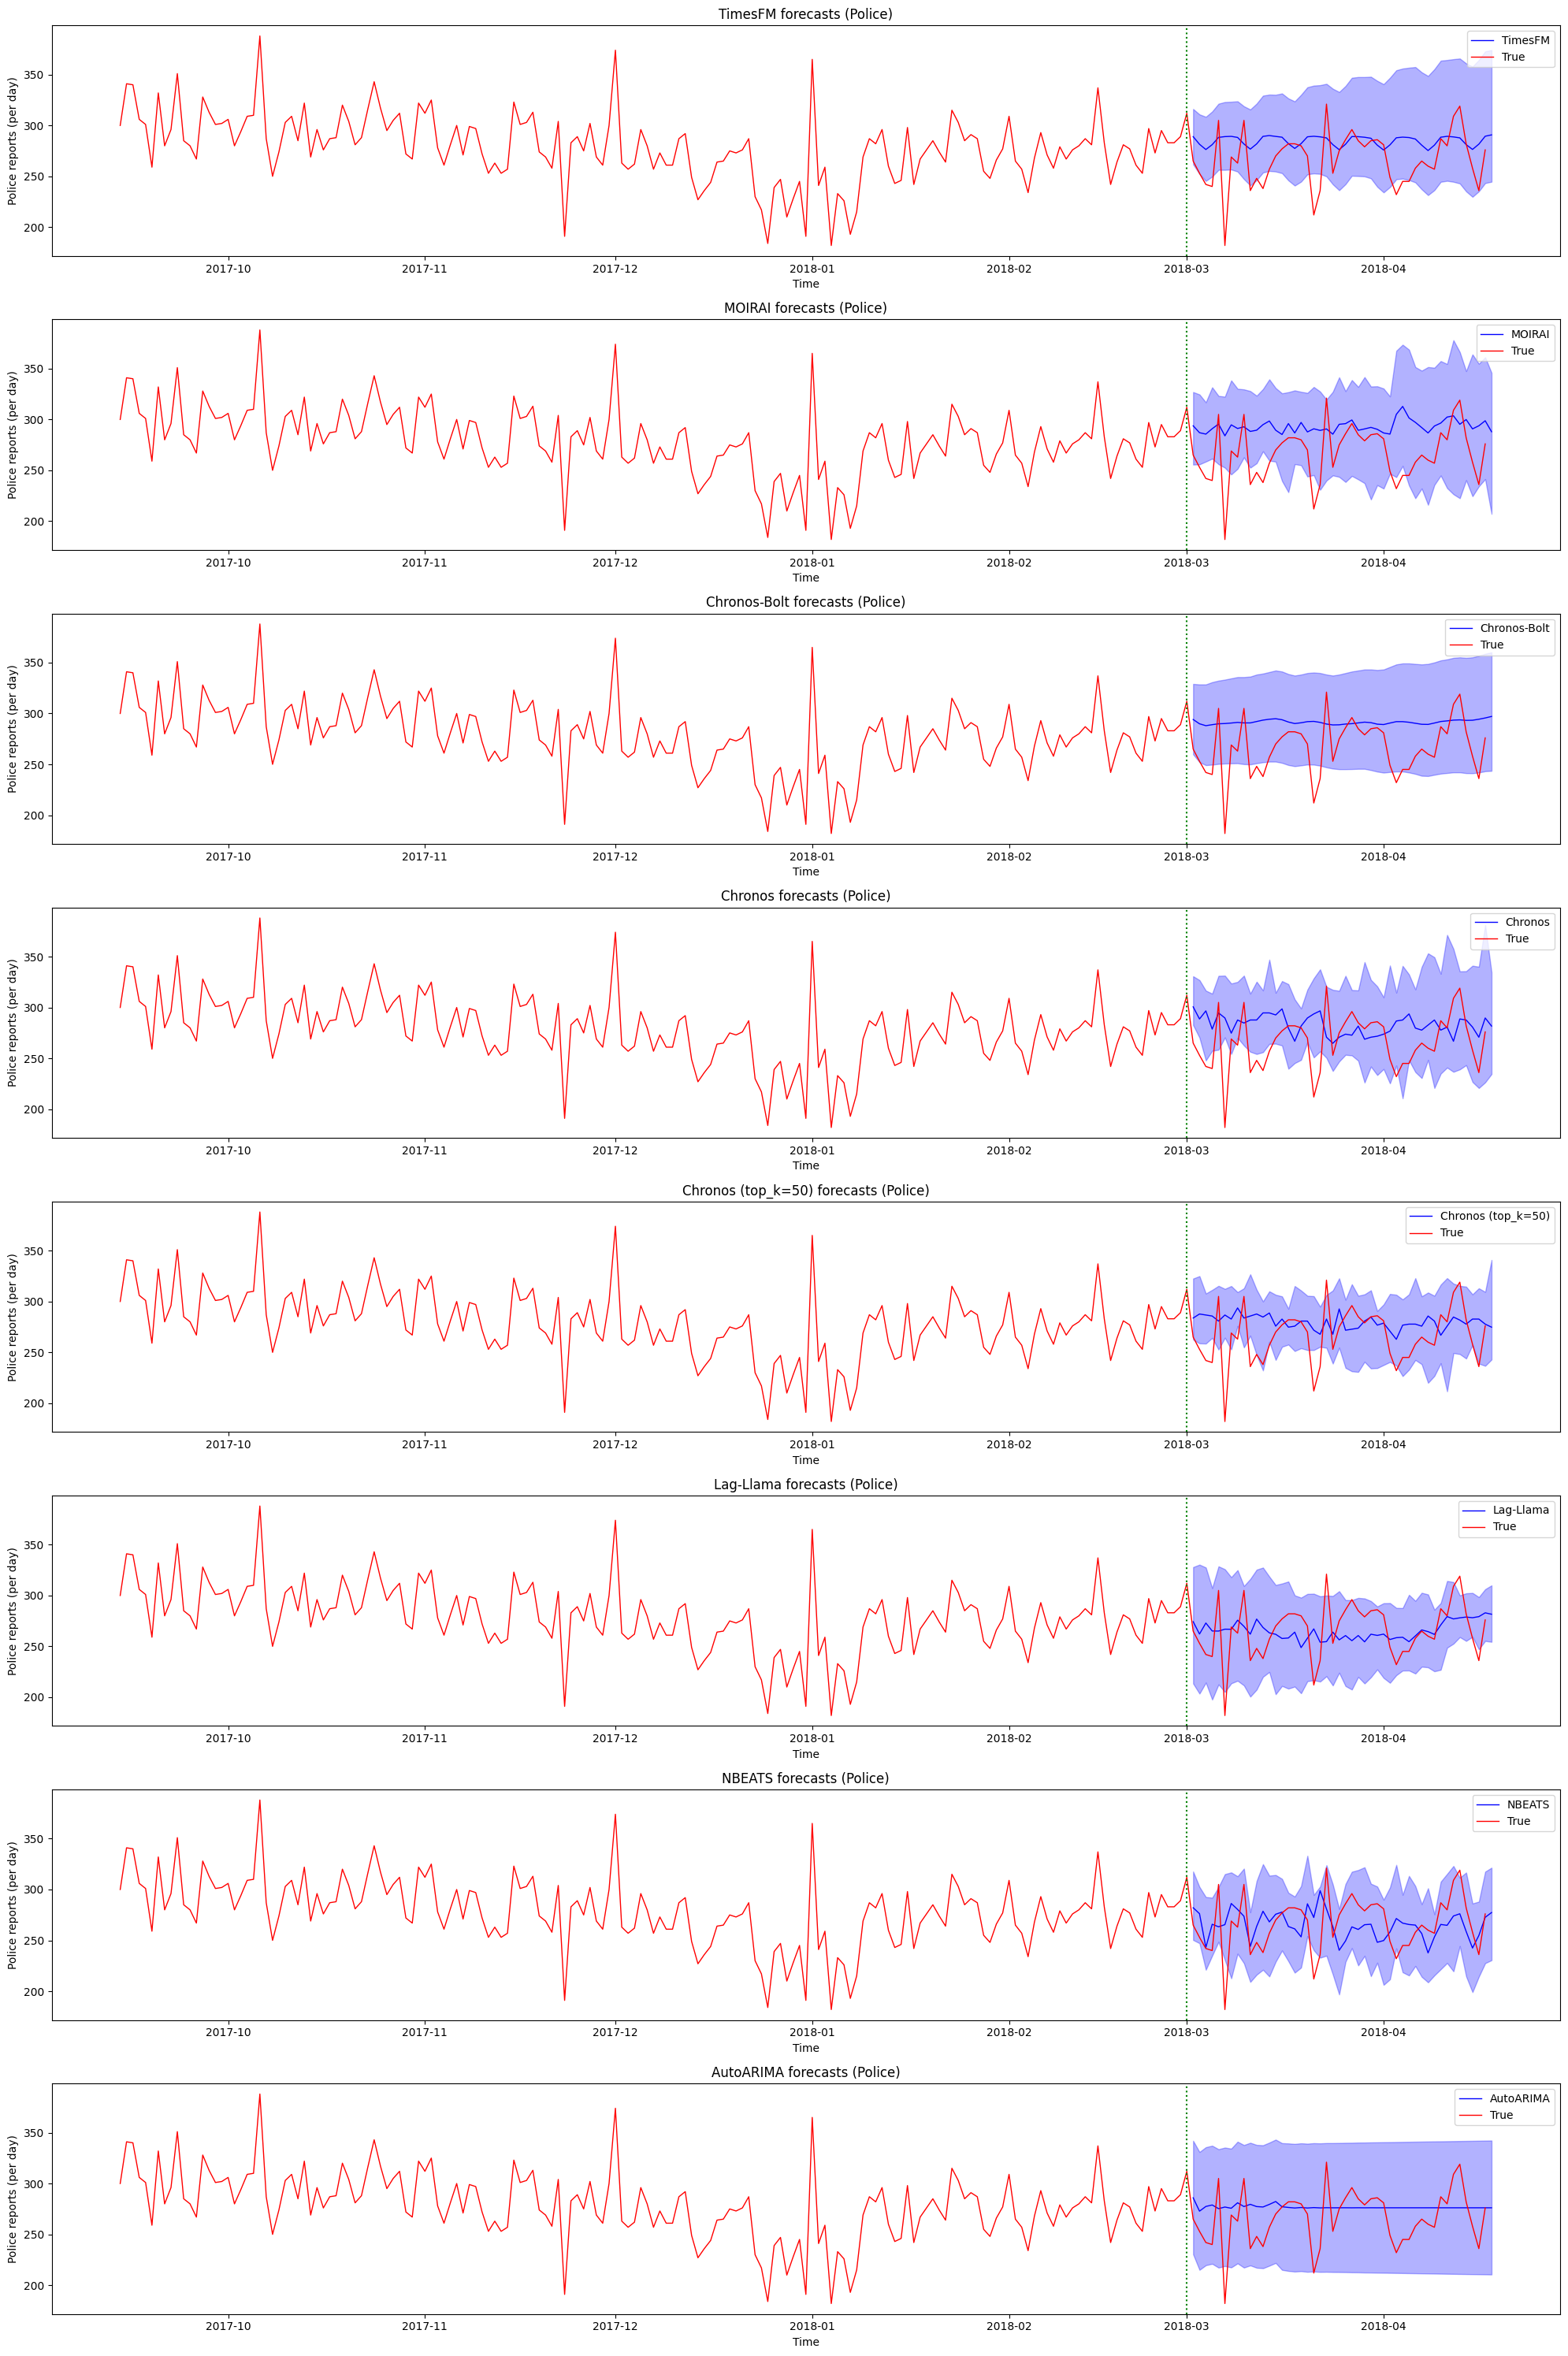

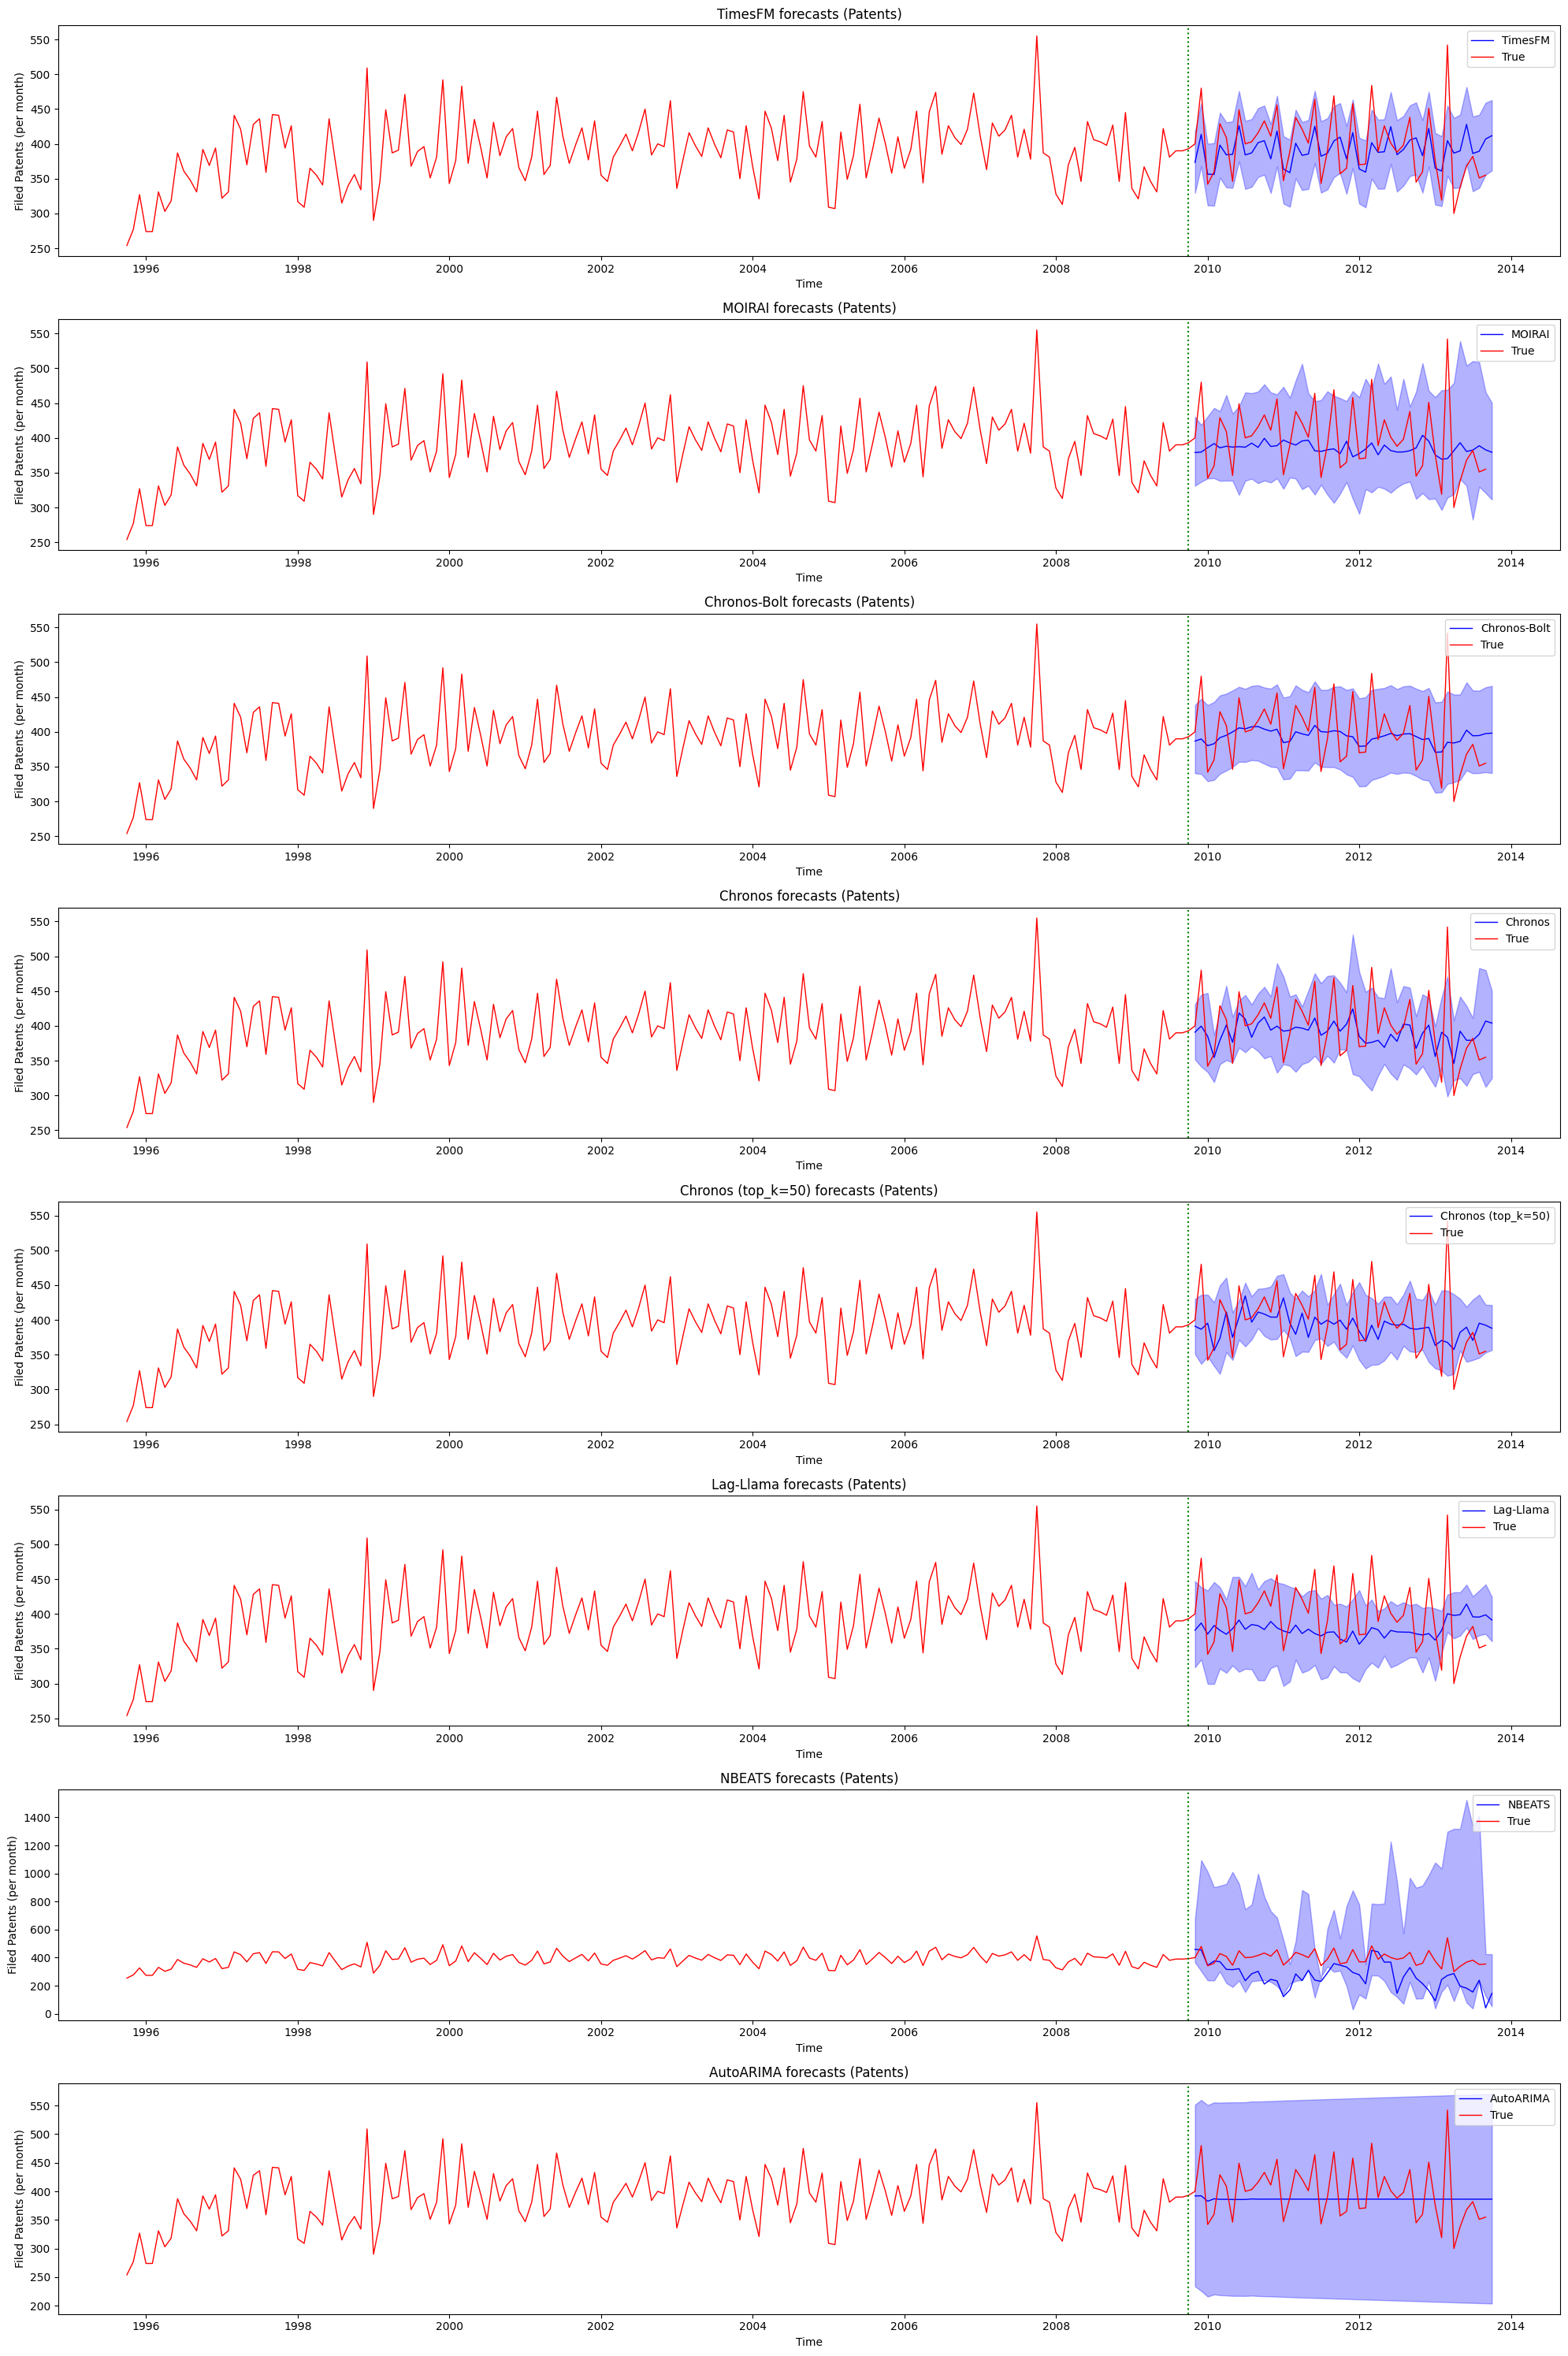

In [ ]:
UNIT_DICT = {"amazon-google": "H", "m5": "D", "glucose": "T", "meditation": "S", "amazon": "H", "patents": "M", "police": "D",
             "m5_small": "D", "meditation_small": "S", "glucose_small": "T", "patents_small": "M", "police_small": "D"}
UNIT_NUM_DICT = {"amazon-google": 1, "m5": 1, "glucose": 5, "meditation": 1, "amazon": 1, "patents": 1, "police": 1,
                 "m5_small": 1, "meditation_small": 1, "glucose_small": 5, "patents_small": 1, "police_small": 1}

steps_ahead = 48
# freq_delta = pd.Timedelta(UNIT_NUM_DICT[dataset], unit=UNIT_DICT[dataset])

# start_time = pd.Timestamp('2021-02-09 00:00')
start_times = [pd.Timestamp('2021-02-09 00:00'), 
               pd.Timestamp('2015-09-01'), 
               pd.Timestamp('2020-02-17 12:43:00'), 
               pd.Timestamp('2000-01-01 00:06:30'),
               pd.Timestamp('2018-03-01'),
               pd.Timestamp('2009-10')]
ids = [2,0,0,0,0,0]
# id = 1
# freq_delta = pd.Timedelta(1, unit='h')
# dataset = 'amazon-google'
models = ['timesfm', 'moirai', 'chronos-bolt_top_k', 'chronos_top_k', 'chronos', 'lag-llama-context', 'nbeats-config', 'autoarima']
model_names = ['TimesFM', "MOIRAI", 'Chronos-Bolt', 'Chronos', 'Chronos (top_k=50)', 'Lag-Llama', "NBEATS", 'AutoARIMA']
datasets = ['amazon-google', 'm5', 'glucose', 'meditation', 'police', 'patents']
dataset_names =  ['Reviews', 'M5', 'Glucose', 'Heart-Rate', 'Police', 'Patents']
y_labels = ["Book Review Count (per hour)", 
            "Products Sold (per day)", 
            "Glucose Levels (mg/dL)", 
            "Heart Rate",
            "Police reports (per day)",
            "Filed Patents (per month)"]

for dataset, dataset_name, y_label, start_time, id in zip(datasets, dataset_names, y_labels, start_times, ids):
    if UNIT_DICT[dataset] == "M":
        freq_delta = pd.DateOffset(months=UNIT_NUM_DICT[dataset])
    else:
        freq_delta = pd.Timedelta(UNIT_NUM_DICT[dataset], unit=UNIT_DICT[dataset])
    _, ax = plt.subplots(len(models), figsize=(20,30))
    for i, (axes, model) in enumerate(zip(ax, models)):
        model_name = model_names[i]
        plot_model(dataset, model, id, start_time, 48, freq_delta, plt_tmp=axes)
        plot_true(dataset, id, start_time, 7*24, 48, freq_delta, plt_tmp=axes)
        axes.axvline(start_time, c='green', ls=':')
        axes.set_title(f"{model_name} forecasts ({dataset_name})")
        axes.set_xlabel("Time")
        axes.set_ylabel(y_label)
        axes.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(f"figures/forecasts_{dataset_name}.png")
    plt.show()

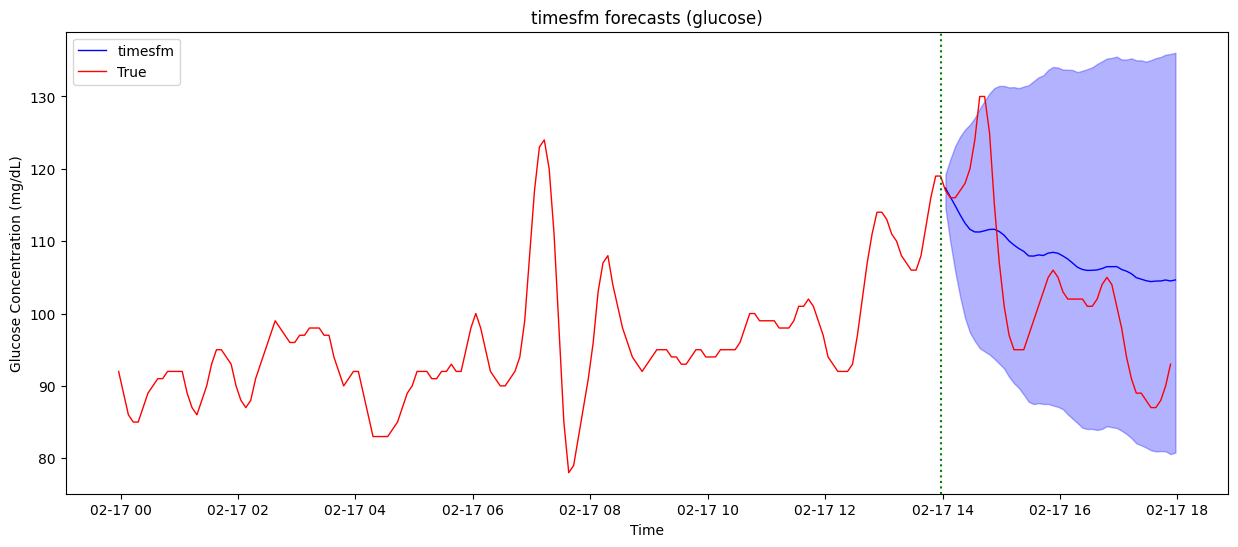

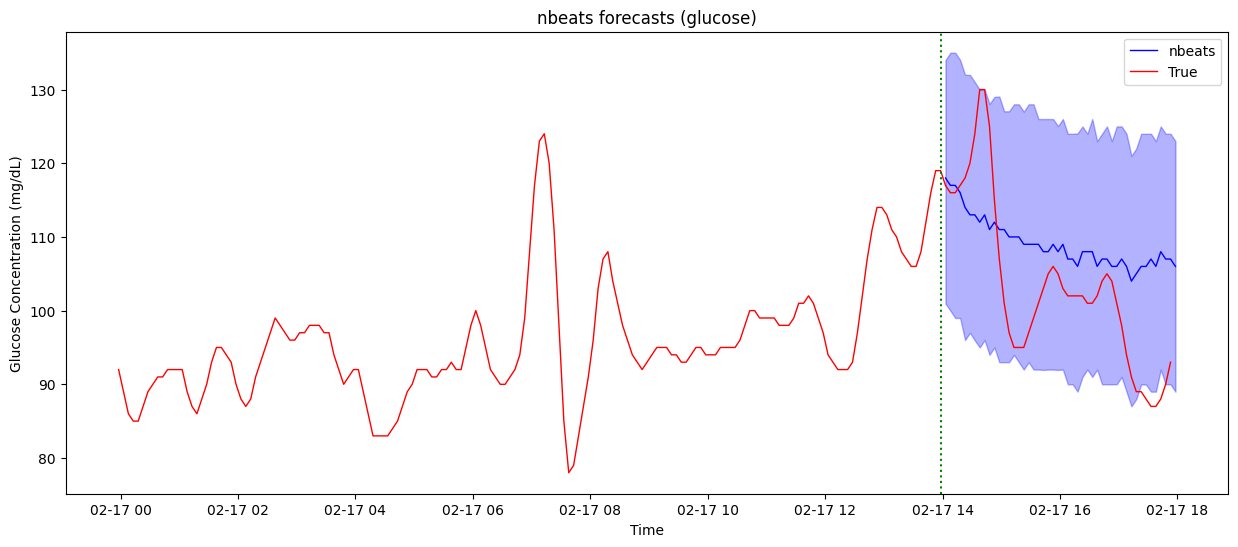

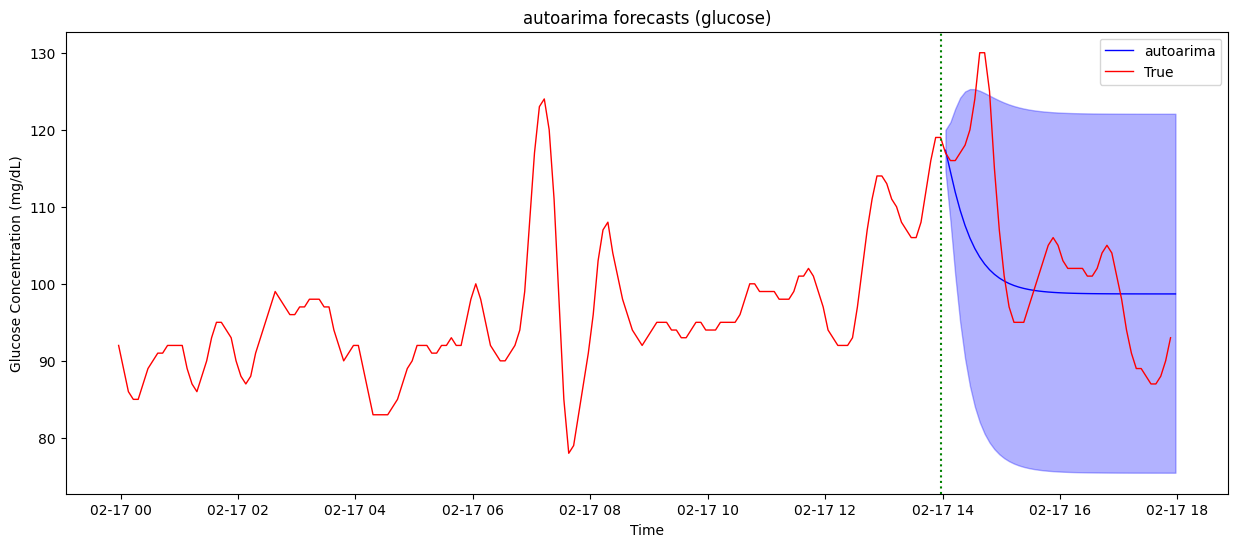

In [ ]:
start_time = pd.Timestamp('2020-02-17 13:58:00')
id = 0
steps_ahead = 48
freq_delta = pd.Timedelta(5, unit='m')
dataset = 'glucose'
models = ['timesfm', 'nbeats', 'autoarima']

for model in models:
    plt.figure(figsize=(15,6))
    plot_model(dataset, model, id, start_time, 48, freq_delta)
    plot_true(dataset, id, start_time, 7*24, 48, freq_delta)
    plt.axvline(start_time, c='green', ls=':')
    plt.title(f"{model} forecasts ({dataset})")
    plt.xlabel("Time")
    plt.ylabel("Glucose Concentration (mg/dL)")
    plt.legend()
    plt.show()

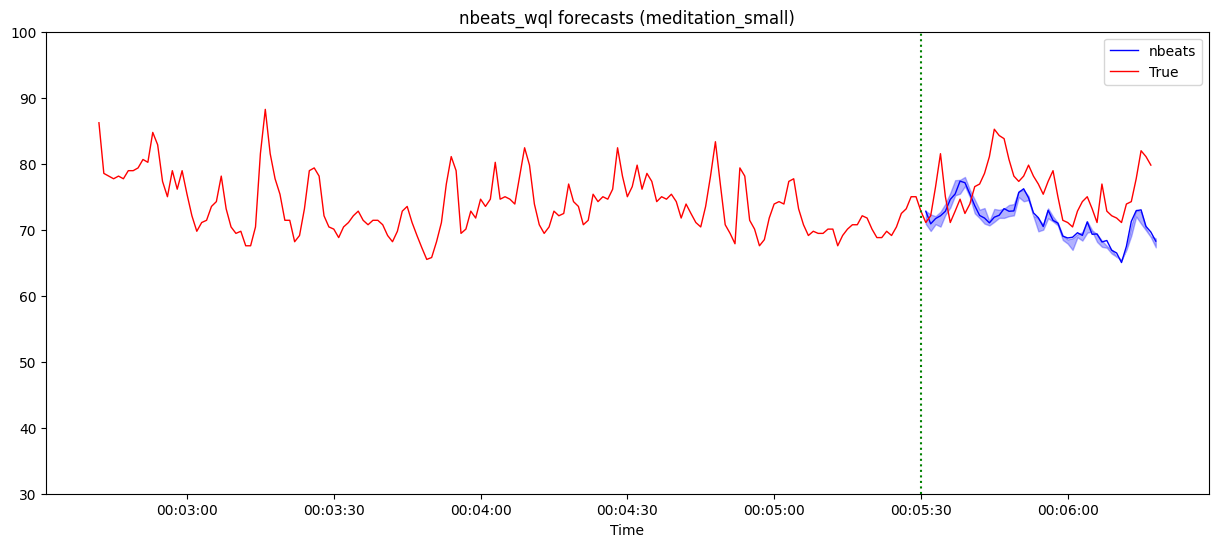

In [84]:
start_time = pd.Timestamp('2000-01-01 00:05:30')
id = 0
steps_ahead = 48
freq_delta = pd.Timedelta(1, unit='S')
dataset = 'meditation_small'
model = 'nbeats_wql'
model_name = 'nbeats'

plt.figure(figsize=(15,6))
plot_model(dataset, model, id, start_time, 48, freq_delta)
plot_true(dataset, id, start_time, 7*24, 48, freq_delta)
plt.axvline(start_time, c='green', ls=':')
plt.ylim(top=100, bottom=30)
plt.title(f"{model} forecasts ({dataset})")
plt.xlabel("Time")
plt.legend()
plt.show()

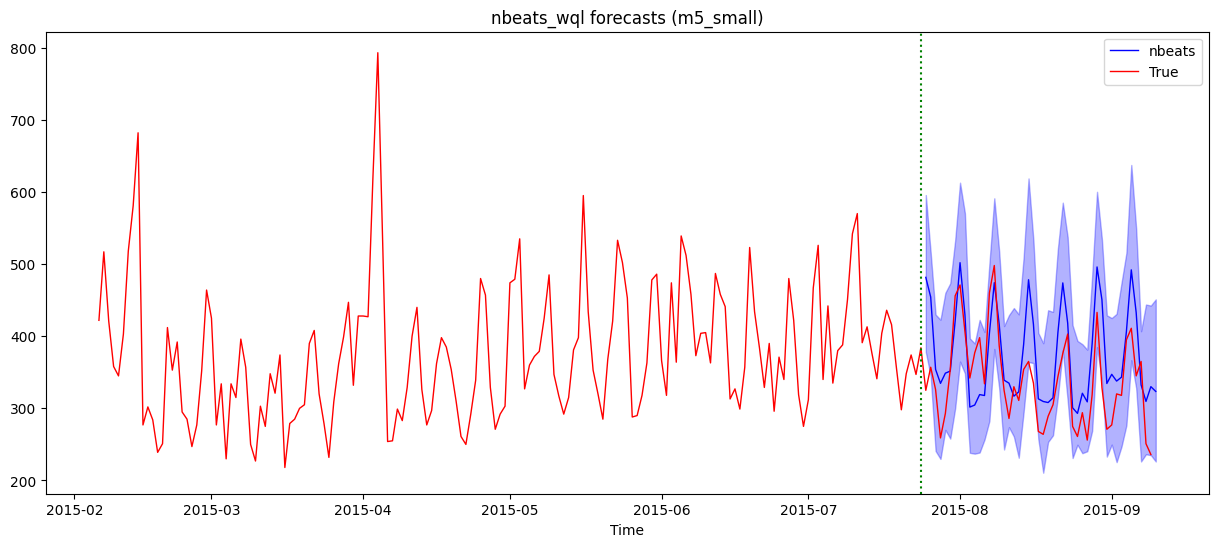

In [92]:
start_time = pd.Timestamp('2015-07-24')
id = 0
steps_ahead = 48
freq_delta = pd.Timedelta(1, unit='D')
dataset = 'm5_small'
model = 'nbeats_wql'
model_name = 'nbeats'

plt.figure(figsize=(15,6))
plot_model(dataset, model, id, start_time, 48, freq_delta)
plot_true(dataset, id, start_time, 7*24, 48, freq_delta)
plt.axvline(start_time, c='green', ls=':')
plt.title(f"{model} forecasts ({dataset})")
plt.xlabel("Time")
plt.legend()
plt.show()

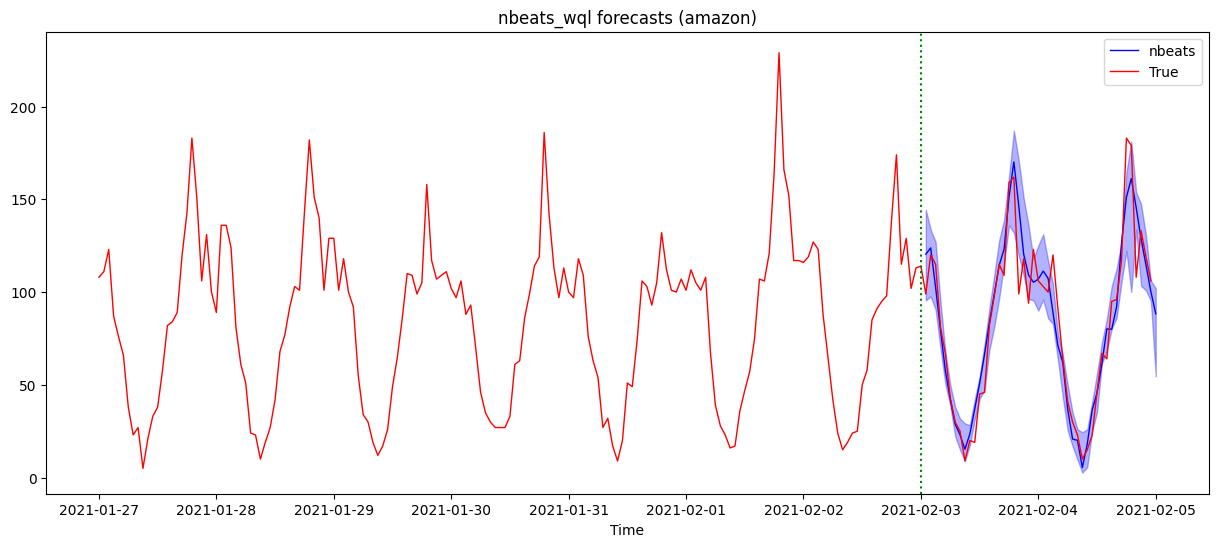

In [94]:
start_time = pd.Timestamp('2021-02-03 00:00')
id = 2
steps_ahead = 48
freq_delta = pd.Timedelta(1, unit='H')
dataset = 'amazon'
model = 'nbeats_wql'
model_name = 'nbeats'

plt.figure(figsize=(15,6))
plot_model(dataset, model, id, start_time, 48, freq_delta)
plot_true(dataset, id, start_time, 7*24, 48, freq_delta)
plt.axvline(start_time, c='green', ls=':')
plt.title(f"{model} forecasts ({dataset})")
plt.xlabel("Time")
plt.legend()
plt.show()

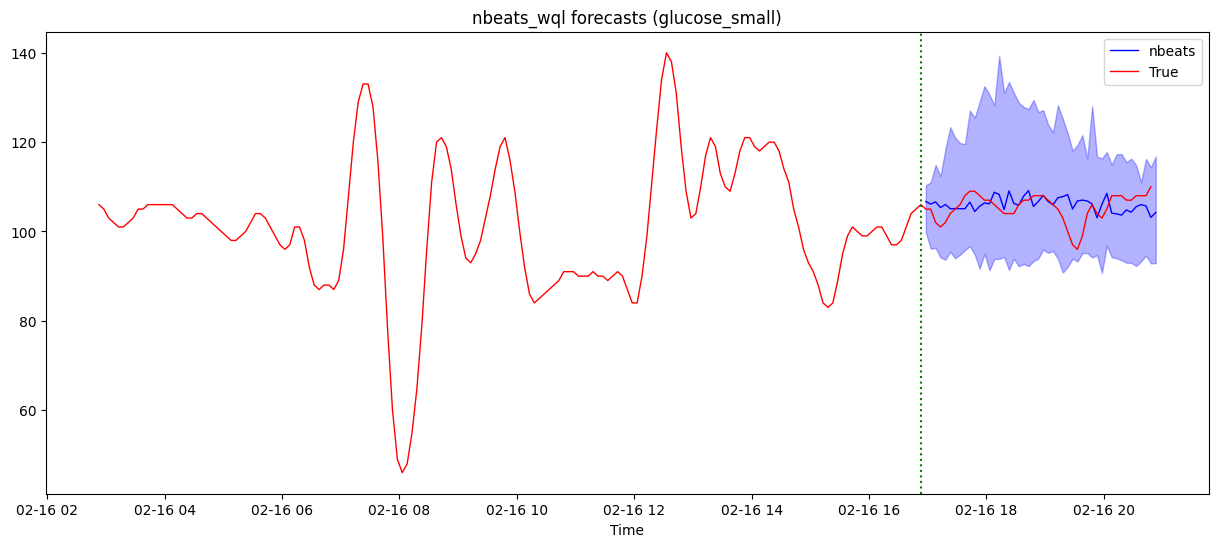

In [105]:
start_time = pd.Timestamp('2020-02-16 16:53:00')
id = 0
steps_ahead = 48
freq_delta = pd.Timedelta(5, unit='T')
dataset = 'glucose_small'
model = 'nbeats_wql'
model_name = 'nbeats'

plt.figure(figsize=(15,6))
plot_model(dataset, model, id, start_time, 48, freq_delta)
plot_true(dataset, id, start_time, 7*24, 48, freq_delta)
plt.axvline(start_time, c='green', ls=':')
plt.title(f"{model} forecasts ({dataset})")
plt.xlabel("Time")
plt.legend()
plt.show()

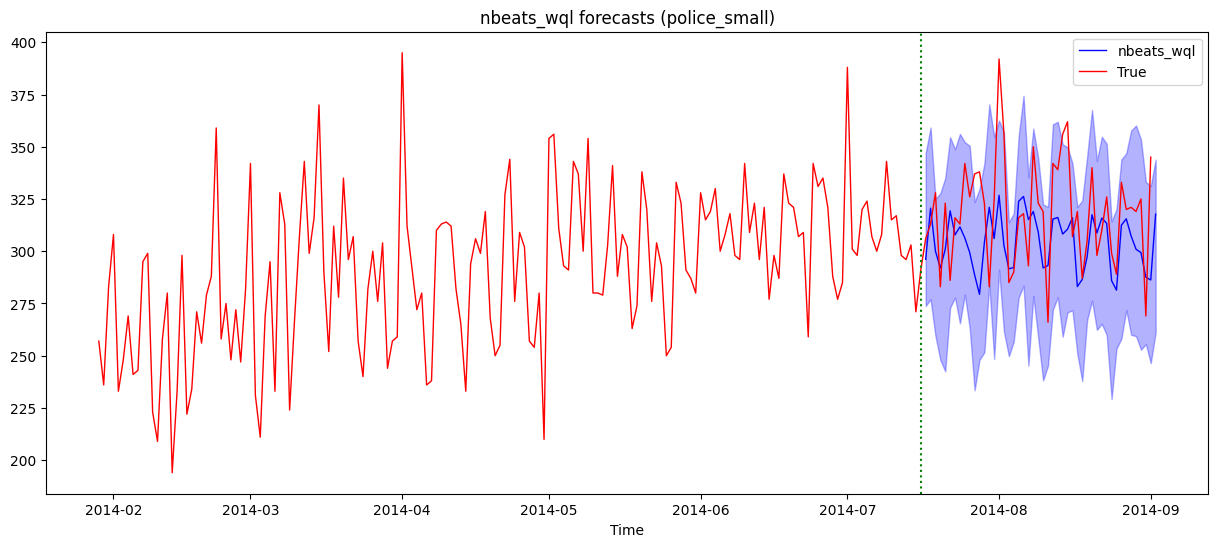

In [134]:
start_time = pd.Timestamp('2014-07-16 00:00:00')
id = 0
steps_ahead = 48
freq_delta = pd.Timedelta(1, unit='d')
dataset = 'police_small'
model = 'nbeats_wql'
model_name = 'nbeats_wql'

plt.figure(figsize=(15,6))
plot_model(dataset, model, id, start_time, 48, freq_delta)
plot_true(dataset, id, start_time, 7*24, 48, freq_delta)
plt.axvline(start_time, c='green', ls=':')
plt.title(f"{model} forecasts ({dataset})")
plt.xlabel("Time")
plt.legend()
plt.show()

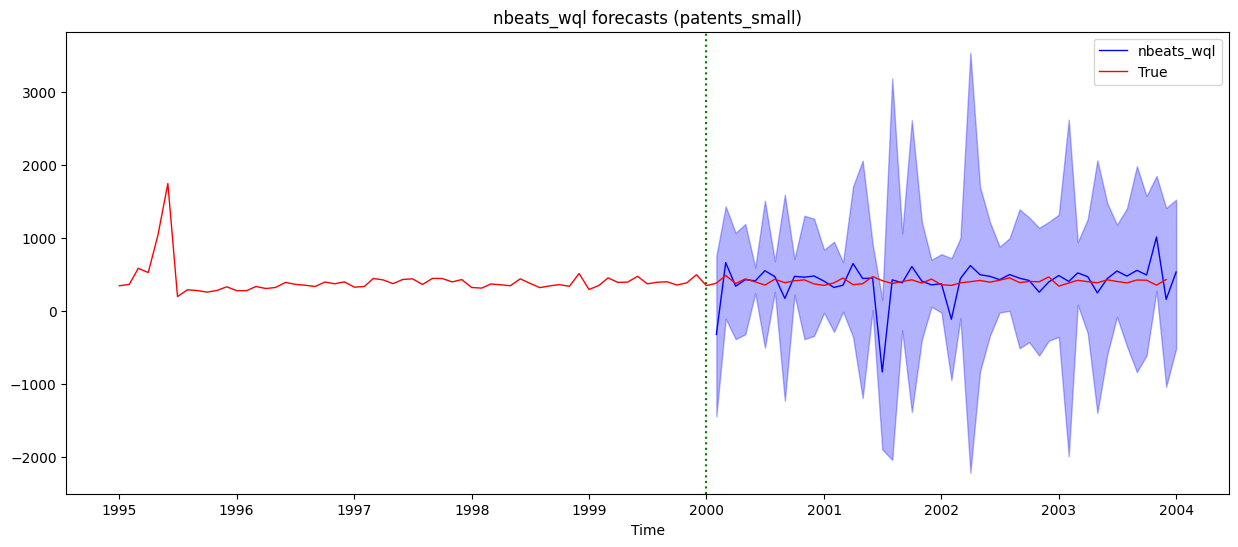

In [131]:
start_time = pd.Timestamp('2000-01-01 00:00:00')
id = 0
steps_ahead = 48
freq_delta = pd.DateOffset(months=1)
dataset = 'patents_small'
model = 'nbeats_wql'
model_name = 'nbeats_wql'

plt.figure(figsize=(15,6))
plot_model(dataset, model, id, start_time, 48, freq_delta)
plot_true(dataset, id, start_time, 5*12, 48, freq_delta)
plt.axvline(start_time, c='green', ls=':')
plt.title(f"{model} forecasts ({dataset})")
plt.xlabel("Time")
plt.legend()
plt.show()